<a href="https://colab.research.google.com/github/Tanishq7361/Dynamical-Systems-Simulation-and-Bifurcation-Analysis/blob/main/Dynamical_Systems_Simulation_and_Bifurcation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamical_Systems_Simulation_and_Bifurcation_Analysis

 ---

# Question 1: Trajectories of an Autonomous System

## Problem Statement

Consider the autonomous system:

$$
\dot{x} = \sin(x)
$$

We integrate this ODE numerically using **Euler’s Method** for the initial conditions:

$$
x(0) = \pm 1,\; \pm 2
$$

---



## ➤ Finding Fixed Points

Fixed points occur where:

$$
\sin(x) = 0
$$

$$
\Rightarrow x = n\pi, \quad n \in \mathbb{Z}
$$

So the points are:

$$
..., -2\pi,\; -\pi,\; 0,\; \pi,\; 2\pi, ...
$$

---

## ➤ Stability Analysis

To determine stability, compute:

$$
f'(x) = \frac{d}{dx} \sin(x) = \cos(x)
$$

Evaluate at equilibrium points:

### At $x = 0, \pm 2\pi, \pm 4\pi, ...$

$$
\cos(x) = 1 > 0
$$

⇒ **Unstable equilibrium (Repulsive)**


### At $x = \pm \pi, \pm 3\pi, ...$

$$
\cos(x) = -1 < 0
$$

⇒ **Stable equilibrium (Attractive)**

---

## ➤ Behavior at Initial Conditions

Given:

- $x(0) = 1$
- $x(0) = -1$
- $x(0) = 2$
- $x(0) = -2$

### For $x(0) = 1$

Since $\sin(1) > 0$,  
$x$ increases and approaches:

$$
x \to \pi
$$

### For $x(0) = 2$

Since $\sin(2) > 0$,  
$x$ increases and approaches:

$$
x \to \pi
$$

### For $x(0) = -1$

Since $\sin(-1) < 0$,  
$x$ decreases and approaches:

$$
x \to -\pi
$$

### For $x(0) = -2$

Since $\sin(-2) < 0$,  
$x$ decreases and approaches:

$$
x \to -\pi
$$

---


## ➤ Asymptotic Behavior ($t \to \infty$)

All trajectories move toward the **nearest stable equilibrium**, which are:

$$
x = \pm \pi, \pm 3\pi, ...
$$

For our chosen initial conditions:

$$
x(t) \to \pi \quad \text{for positive initial values}
$$

$$
x(t) \to -\pi \quad \text{for negative initial values}
$$

Thus, the system settles into **stable steady states**.

---

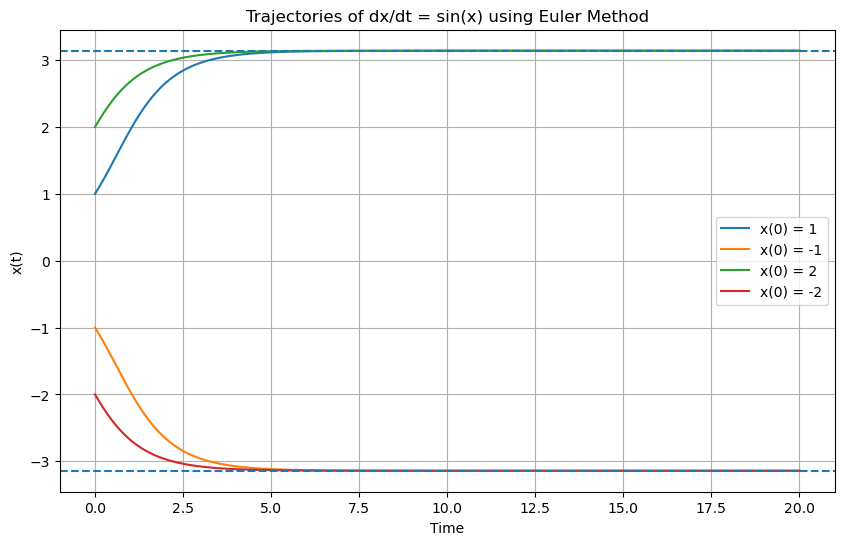

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

def euler_method(f, x0, t0, tf, dt):
    t = np.arange(t0, tf + dt, dt)
    x = np.zeros(len(t))
    x[0] = x0

    for i in range(len(t) - 1):
        x[i+1] = x[i] + dt * f(x[i])

    return t, x

t0 = 0
tf = 20
dt = 0.01

initial_conditions = [1, -1, 2, -2]

plt.figure(figsize=(10,6))

for x0 in initial_conditions:
    t, x = euler_method(f, x0, t0, tf, dt)
    plt.plot(t, x, label=f"x(0) = {x0}")

plt.axhline(np.pi, linestyle="--")
plt.axhline(-np.pi, linestyle="--")

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Trajectories of dx/dt = sin(x) using Euler Method")
plt.legend()
plt.grid(True)

plt.show()



## ➤ Physical Interpretation

The system behaves like motion in a **periodic potential field**.

- Stable equilibria → valleys (min. energy)
- Unstable equilibria → peaks (max. energy)

A particle placed anywhere will:

- Roll away from unstable peaks
- Settle into the nearest valley

---


## ➤ Final Conclusion

- The system has infinitely many equilibria at $x = n\pi$.
- Equilibria alternate between stable and unstable.
- All given trajectories converge to the nearest stable equilibrium.
- The long-term behavior is determined by the initial position.

### Hence, the asymptotic nature of the system is convergence to stable periodic equilibria.

---

# Question 2: Confirming Bifurcation from Trajectories

# (a) Saddle-Node Bifurcation

## Model

$$
\dot{x} = r - x^2
$$

This system depends on the parameter $r$ and undergoes a **saddle-node bifurcation at $r = 0$**.

---

## Fixed Points

Equilibrium points satisfy:

$$
r - x^2 = 0
$$

$$
\Rightarrow x = \pm \sqrt{r}
$$

---

## Case Analysis

### ➤ Case 1: $r < 0$

- No real solutions for $\sqrt{r}$
- No fixed points exist
- All trajectories diverge

✔ System has **no equilibrium states**

---

### ➤ Case 2: $r = 0$

$$
\dot{x} = -x^2
$$

- One equilibrium at:

$$
x = 0
$$

- This equilibrium is **semi-stable**
  - Stable from right
  - Unstable from left

✔ Two equilibria merge into one

---

### ➤ Case 3: $r > 0$

$$
x = \pm \sqrt{r}
$$

Two equilibria appear.

To determine stability:

$$
f'(x) = -2x
$$

- At $x = +\sqrt{r}$:

  $$
  f'(x) < 0
  $$
  ⇒ **Stable**

- At $x = -\sqrt{r}$:

  $$
  f'(x) > 0
  $$
  ⇒ **Unstable**

✔ One stable and one unstable equilibrium

---

## Conclusion for (a)

- For $r < 0$ → No equilibria
- At $r = 0$ → One semi-stable equilibrium
- For $r > 0$ → Two equilibria (one stable, one unstable)

Thus, at $r = 0$, a **pair of equilibria is created**.

This confirms it is Saddle-Node Bifurcation.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def saddle_node(x, r):
    return r - x**2

x = np.linspace(-3, 3, 400)

def plot_phase(r):
    plt.figure(figsize=(8,5))

    dxdt = saddle_node(x, r)
    plt.plot(x, dxdt, label="dx/dt = r - x^2")

    if r >= 0:
        eq = np.sqrt(r)
        plt.axvline(eq, linestyle='--')
        plt.axvline(-eq, linestyle='--')

    plt.axhline(0)
    plt.title(f"Phase Plot: dx/dt vs x  (r = {r:.2f})")
    plt.xlabel("x")
    plt.ylabel("dx/dt")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_phase, r=(-2.0, 2.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

# (b) Transcritical Bifurcation

## Model

$$
\dot{x} = r x - x^2
$$

This system undergoes a **transcritical bifurcation at $r = 0$**.

---

## Fixed Points

Set:

$$
r x - x^2 = 0
$$

Factor:

$$
x(r - x) = 0
$$

$$
\Rightarrow x = 0 \quad \text{or} \quad x = r
$$

There are always two equilibrium points.

---

## Stability Analysis

Derivative:

$$
f'(x) = r - 2x
$$

### ➤ At $x = 0$

$$
f'(0) = r
$$

- If $r < 0$ → Stable
- If $r > 0$ → Unstable

### ➤ At $x = r$

$$
f'(r) = r - 2r = -r
$$

- If $r < 0$ → Unstable
- If $r > 0$ → Stable

## What Happens at $r = 0$?

- Both equilibria meet at $x = 0$
- Their stability is exchanged

✔ The fixed points **intersect and exchange stability**

---

# Conclusion for (b)

- Two equilibria always exist.
- At $r = 0$, they collide.
- Stability swaps between them.

This confirms it is a Transcritical Bifurcation.

---

# Final Summary

| System | Type of Bifurcation | What Happens at r = 0 |
|--------|--------------------|-----------------------|
| $\dot{x} = r - x^2$ | Saddle-Node | Two equilibria are created/destroyed |
| $\dot{x} = rx - x^2$ | Transcritical | Equilibria exchange stability |

---

Numerical simulations using Euler’s method confirm both bifurcations clearly.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def transcritical(x, r):
    return r*x - x**2

x = np.linspace(-3, 3, 400)

def plot_phase(r):
    plt.figure(figsize=(8,5))

    dxdt = transcritical(x, r)
    plt.plot(x, dxdt, label="dx/dt = r*x - x^2")

    plt.axvline(0, linestyle='--')
    plt.axvline(r, linestyle='--')

    plt.axhline(0)
    plt.title(f"Phase Plot: dx/dt vs x  (r = {r:.2f})")
    plt.xlabel("x")
    plt.ylabel("dx/dt")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_phase, r=(-2.0, 2.0, 0.1));


interactive(children=(FloatSlider(value=0.0, description='r', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

# Question 3: Duffing-Type System (Low Acceleration Model)

---

## System

We consider the nonlinear autonomous system:

$$
\dot{x} = r - \alpha x - \beta x^3
$$

Here:

- $r$ → bifurcation (control) parameter  
- $\alpha$ → linear damping/stiffness parameter  
- $\beta$ → nonlinear stiffness parameter  

This system is related to the **Duffing oscillator**.

---

# Fixed Points

Equilibria satisfy:

$$
r - \alpha x - \beta x^3 = 0
$$

Rewriting:

$$
\beta x^3 + \alpha x - r = 0
$$

This is a **cubic equation**, so it may have:

- One real equilibrium  
- Three real equilibria  

depending on parameter values.

---

# Stability Analysis

To determine stability, compute:

$$
f'(x) = \frac{d}{dx}(r - \alpha x - \beta x^3)
$$

$$
f'(x) = -\alpha - 3\beta x^2
$$

Stability condition:

- If $f'(x^*) < 0$ → Stable equilibrium  
- If $f'(x^*) > 0$ → Unstable equilibrium  

---

# Parameter Cases

The behavior depends strongly on signs of $\alpha$ and $\beta$.

---

## Case A: $\alpha > 0$, $\beta > 0$

As $|x|$ becomes large:

$$
-\beta x^3 \to -\infty
$$

Typical behavior:

- For most values of r there is only one equilibrium which shifts with shifting fixed point and for some values of r there also exist 3 equlibirum.The cubic term adds a stronger restoring force at large $x$. The system always has atleast one real fixed point which is stable. All trajectories converge monotonically — no bifurcation occurs as $r$ varies; the fixed point simply shifts.

---

## Case B: $\alpha > 0$, $\beta < 0$

The $-\beta x^3$ term (with $\beta < 0$, so $+|\beta|x^3$) destabilizes at large $x$. For $|r| < r_c$, there are three fixed points (one stable, one unstable, one stable). A **saddle-node bifurcation** occurs at $r = \pm r_c$ where two fixed points collide and annihilate. This leads to bistability and hysteresis.

---

## Case C: $\alpha < 0$, $\beta > 0$

For $r = 0$, $x^* = 0$ is unstable (since $f'(0) = -\alpha > 0$) and two symmetric stable fixed points exist at $x^* = \pm\sqrt{-\alpha/\beta}$. As $r$ varies away from zero, the symmetry breaks and one fixed point becomes dominant — this is related to **spontaneous symmetry breaking**.

---

# Possible Bifurcations

As parameter $r$ changes:

- The number of equilibria can change.
- A **saddle-node bifurcation** may occur.
- In symmetric cases, pitchfork-type behavior can appear.

Thus, depending on parameters, this system can exhibit:

- Monostability
- Bistability
- Sudden transitions between states

---

# Physical Interpretation

This equation is derived from the **Duffing oscillator**, which models a nonlinear spring.

The classical Duffing equation (second-order form) is:

$$
\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = F
$$

In the overdamped (low acceleration) limit:

$$
\dot{x} = r - \alpha x - \beta x^3
$$

---

# BY OUR READINGS:

## Origin of the $x^3$ Term

The cubic term arises from:

- Nonlinear restoring forces
- Non-Hookean springs
- Geometric nonlinearities
- Material nonlinear stiffness

In real systems:

- If $\beta > 0$ → **Hardening spring**
- If $\beta < 0$ → **Softening spring**

# Applications

This model appears in:

- Mechanical oscillators  
- Electrical circuits  
- Climate dynamics  
- Laser physics  
- Structural engineering  

It is one of the most studied nonlinear systems.

---

# Final Conclusion

The system:

$$
\dot{x} = r - \alpha x - \beta x^3
$$

- Is a nonlinear cubic dynamical system  
- Can have one or three equilibria  
- Stability depends on $\alpha$ and $\beta$  
- Exhibits saddle-node–type bifurcations  
- Models nonlinear oscillatory phenomena  

The cubic term introduces nonlinearity that leads to bistability and rich dynamical behavior.

---

 Hence, the Duffing-type system exhibits nonlinear stability behavior and parameter-dependent bifurcations.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

alpha = 1
beta = 1

def duffing_like(x, r):
    return r - alpha*x - beta*x**3

x = np.linspace(-3, 3, 600)

def plot_phase(r):
    plt.figure(figsize=(8,5))

    dxdt = duffing_like(x, r)
    plt.plot(x, dxdt, label=r"$\dot{x} = r - \alpha x - \beta x^3$")

    roots = np.roots([beta, 0, alpha, -r])  # βx^3 + αx - r = 0

    for root in roots:
        if np.isreal(root):
            plt.axvline(root.real, linestyle='--')

    plt.axhline(0)
    plt.title(f"Case A: α>0, β>0   (r = {r:.2f})")
    plt.xlabel("x")
    plt.ylabel("dx/dt")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_phase, r=(-3.0, 3.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

alpha = 1
beta = -1

def duffing_like(x, r):
    return r - alpha*x - beta*x**3

x = np.linspace(-3, 3, 600)

def plot_phase(r):
    plt.figure(figsize=(8,5))

    dxdt = duffing_like(x, r)
    plt.plot(x, dxdt, label=r"$\dot{x} = r - \alpha x - \beta x^3$")

    roots = np.roots([beta, 0, alpha, -r])  # βx^3 + αx - r = 0

    for root in roots:
        if np.isreal(root):
            plt.axvline(root.real, linestyle='--')

    plt.axhline(0)
    plt.title(f"Case B: α>0, β<0   (r = {r:.2f})")
    plt.xlabel("x")
    plt.ylabel("dx/dt")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_phase, r=(-3.0, 3.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

alpha = -1
beta = 1

def duffing_like(x, r):
    return r - alpha*x - beta*x**3

x = np.linspace(-3, 3, 600)

def plot_phase(r):
    plt.figure(figsize=(8,5))

    dxdt = duffing_like(x, r)
    plt.plot(x, dxdt, label=r"$\dot{x} = r - \alpha x - \beta x^3$")

    roots = np.roots([beta, 0, alpha, -r])  # βx^3 + αx - r = 0

    for root in roots:
        if np.isreal(root):
            plt.axvline(root.real, linestyle='--')

    plt.axhline(0)
    plt.title(f"Case C: α<0, β>0   (r = {r:.2f})")
    plt.xlabel("x")
    plt.ylabel("dx/dt")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_phase, r=(-3.0, 3.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…